# 电商首次加购后 48 小时结果与品牌运营优先级

## tl;dr

- 正式分析对象是有效 `user_session × product_id` 的首次观测加购，不是“人数”。
- 48 小时结果必须同时保留购买 A、未明确处置 B、移除 C，不能只看 A/C。
- 品牌四象限是排查优先级，不是因果风险模型；未知品牌不参与排名。
- 本 Notebook 只读取已由只读 SQL 和 Python 对账通过的正式导出，不扫描 4GB 级内存数据，也不包含数据库密码。

## Context & Methods

### Key Assumptions

1. 事件时间统一按 UTC 解释，业务时区未知。
2. 主窗口为首次观测加购后 48 小时；只保留能完整观察 48 小时的样本。
3. 窗口内购买优先：有购买为 A；无购买但有移除为 C；两者都没有为 B。
4. 空值或 `NaN/null/none` 会话占位符被排除，避免跨用户串联。
5. 品牌 `NaN/null/none` 作为未知品牌，不参与品牌排名。
6. `C/A` 正式名称为“移除/购买比”，只是描述性信号。

生成正式数据的入口：`scripts/run_formal_validation.py`。SQL 位于 `sql/formal/`，全部只读。

## Data

### 1. 加载正式聚合与验证输出

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
project_candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    path for path in project_candidates
    if (path / "reports" / "data_exports").exists()
)
EXPORT_DIR = PROJECT_ROOT / "reports" / "data_exports"
CHART_DIR = PROJECT_ROOT / "reports" / "formal_charts"

kpi = pd.read_csv(EXPORT_DIR / "kpi_summary_48h.csv")
quality = pd.read_csv(EXPORT_DIR / "cohort_quality.csv")
brands = pd.read_csv(EXPORT_DIR / "brand_metrics_48h.csv")
sensitivity = pd.read_csv(EXPORT_DIR / "window_sensitivity.csv")
reconciliation = pd.read_csv(EXPORT_DIR / "reconciliation_summary.csv")

print(f"Project root: {PROJECT_ROOT}")
print(f"Validated brand rows: {len(brands):,}")

Project root: C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History
Validated brand rows: 97


### 2. 验证输入是否可用于正式结论

In [2]:
error_checks = reconciliation.loc[
    (~reconciliation["passed"].astype(bool))
    & reconciliation["severity"].eq("error")
]
warning_checks = reconciliation.loc[
    (~reconciliation["passed"].astype(bool))
    & reconciliation["severity"].eq("warning")
]

assert error_checks.empty, "正式 SQL 与 Python 对账仍有错误"
assert int(quality.loc[0, "duplicate_session_product_excess_rows"]) == 0
assert int(quality.loc[0, "inconsistent_label_rows"]) == 0

pd.DataFrame(
    {
        "检查": ["正式对账错误", "历史版本警告", "主队列联合键重复", "标签不一致"],
        "数量": [
            len(error_checks),
            len(warning_checks),
            int(quality.loc[0, "duplicate_session_product_excess_rows"]),
            int(quality.loc[0, "inconsistent_label_rows"]),
        ],
    }
)

,检查,数量
0,正式对账错误,0
1,历史版本警告,1
2,主队列联合键重复,0
3,标签不一致,0


## Results

### 3. 48 小时主 KPI

In [3]:
headline = kpi.loc[0, [
    "cohort_count",
    "purchase_rate_pct",
    "unresolved_rate_pct",
    "remove_rate_pct",
    "clear_purchase_rate_pct",
    "remove_to_purchase_ratio",
    "known_brand_coverage_pct",
]].to_frame("value")
headline

,value
cohort_count,772119.0000
purchase_rate_pct,13.5596
unresolved_rate_pct,66.2185
remove_rate_pct,20.2219
clear_purchase_rate_pct,40.1391
remove_to_purchase_ratio,1.4913
known_brand_coverage_pct,55.9880


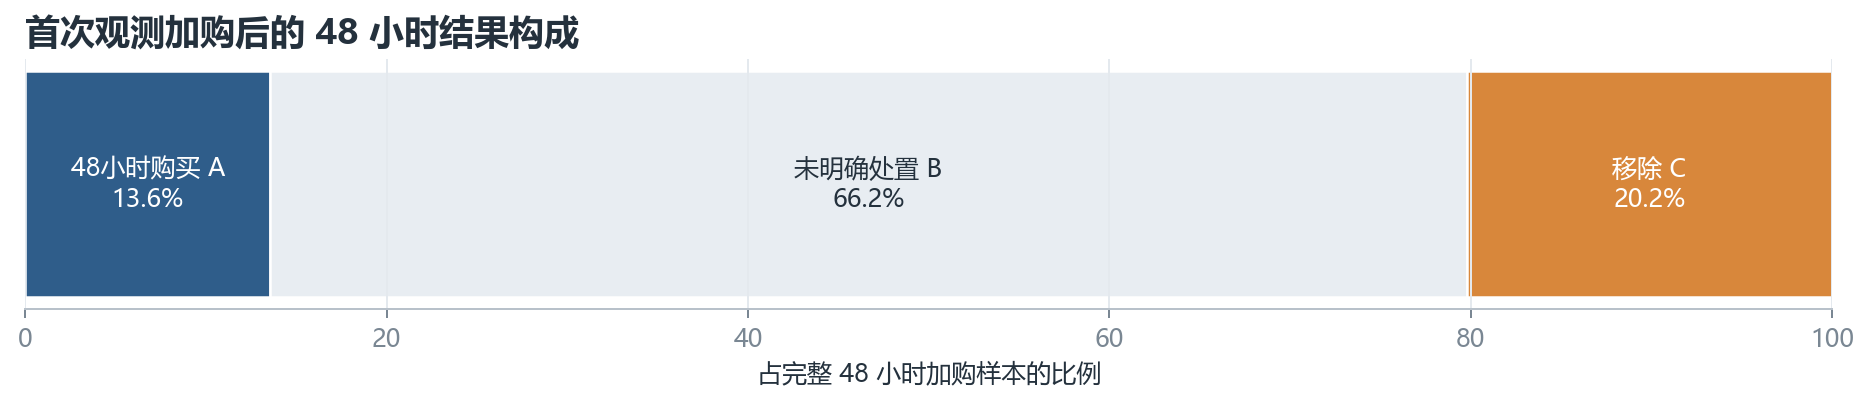

In [4]:
display(Image(filename=str(CHART_DIR / "11_outcome_mix_48h.png"), width=1000))

**解释：** 整体 48 小时购买率使用 A/(A+B+C)。“明确结果购买率”只使用 A/(A+C)，两者回答不同问题。由于 B 占多数，管理层看板不能只展示 A/C。

### 4. 时间窗口敏感性

In [5]:
sensitivity[[
    "window_hours",
    "common_cohort_count",
    "purchase_rate_pct",
    "unresolved_rate_pct",
    "remove_rate_pct",
    "remove_to_purchase_ratio",
]]

,window_hours,common_cohort_count,purchase_rate_pct,unresolved_rate_pct,remove_rate_pct,remove_to_purchase_ratio
0,24,756116,13.5758,66.2423,20.1818,1.4866
1,48,756116,13.6012,66.1389,20.2599,1.4896
2,72,756116,13.6188,66.0819,20.2993,1.4905


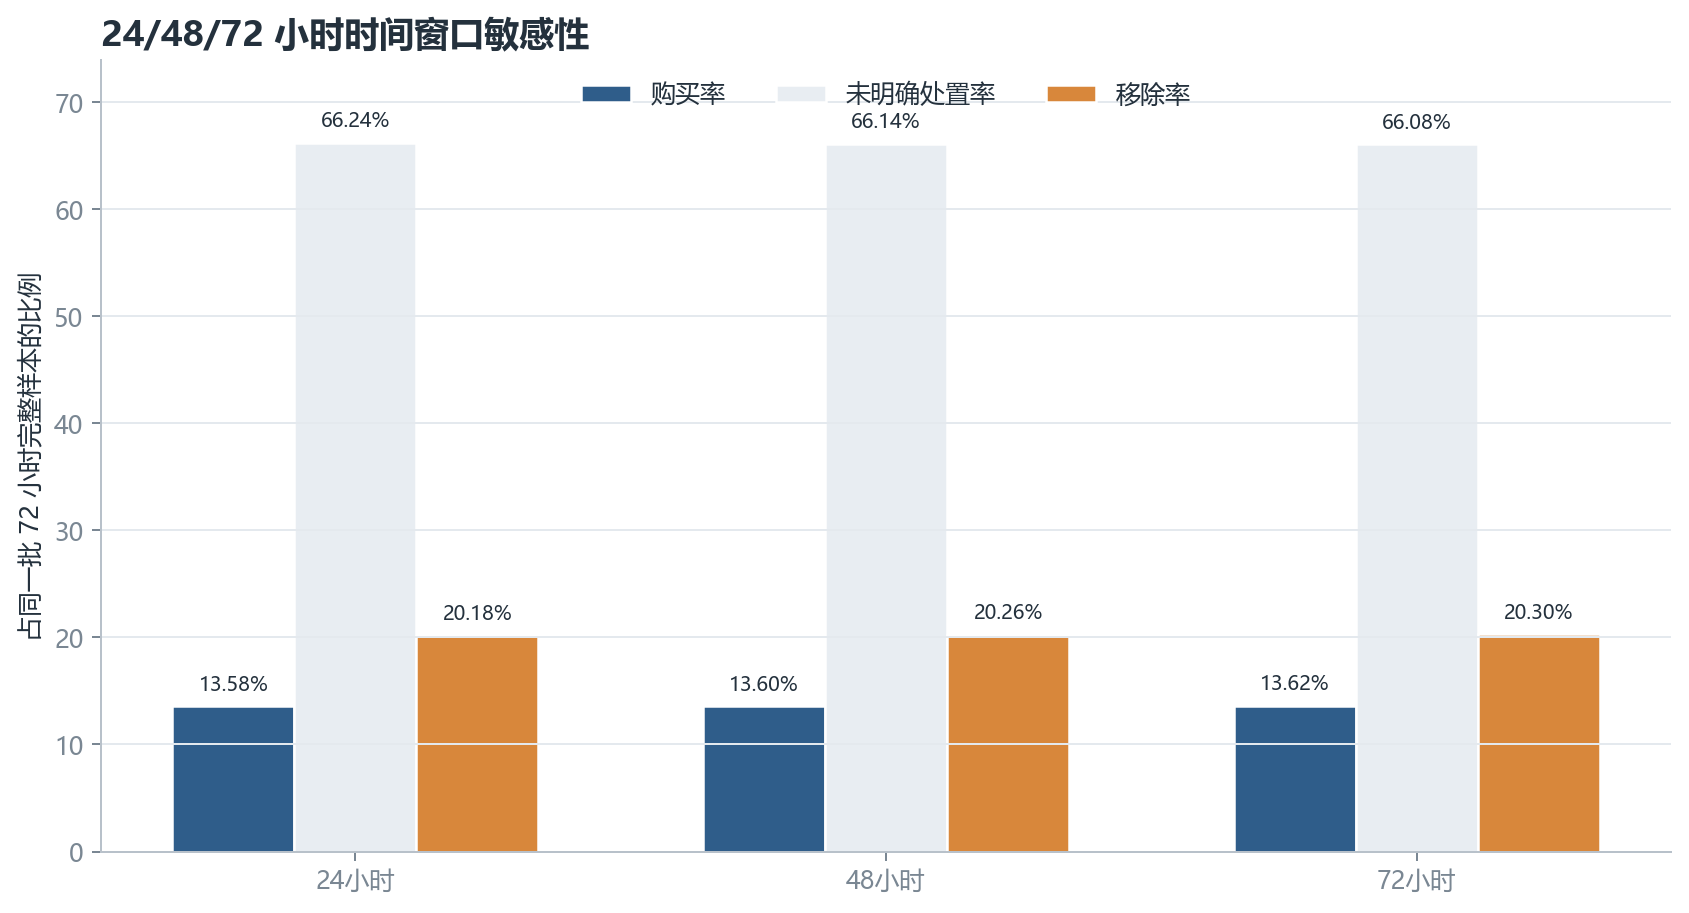

In [6]:
display(Image(filename=str(CHART_DIR / "12_window_sensitivity.png"), width=900))

**解释：** 三个窗口使用同一批能完整观察 72 小时的样本，因此差异来自窗口延长，而不是月末样本变化。总体购买率只小幅变化；这不等于所有品牌排名都稳定。

### 5. 已知品牌运营排查优先级

In [7]:
priority_brands = (
    brands.loc[brands["priority_quadrant"].eq("优先核查")]
    .sort_values(["brand_cohort_count", "remove_to_purchase_ratio"], ascending=[False, False])
)
priority_brands[[
    "brand",
    "brand_cohort_count",
    "purchase_rate_pct",
    "unresolved_rate_pct",
    "remove_rate_pct",
    "remove_to_purchase_ratio",
]].head(12)

,brand,brand_cohort_count,purchase_rate_pct,unresolved_rate_pct,remove_rate_pct,remove_to_purchase_ratio
0,grattol,33335,12.1794,68.2796,19.5410,1.6044
1,masura,30929,10.4627,65.3755,24.1618,2.3093
2,ingarden,15682,12.3135,68.0653,19.6212,1.5935
3,pole,12249,12.7112,62.8378,24.4510,1.9236
4,bluesky,9634,10.6083,64.3554,25.0363,2.3601
5,haruyama,7327,11.0959,65.3337,23.5704,2.1242
6,cosmoprofi,4403,8.9712,67.8174,23.2114,2.5873
7,lovely,4316,12.7896,67.7711,19.4393,1.5199
8,lianail,4168,11.4683,69.1699,19.3618,1.6883
9,f.o.x,4129,10.4868,65.1489,24.3643,2.3233


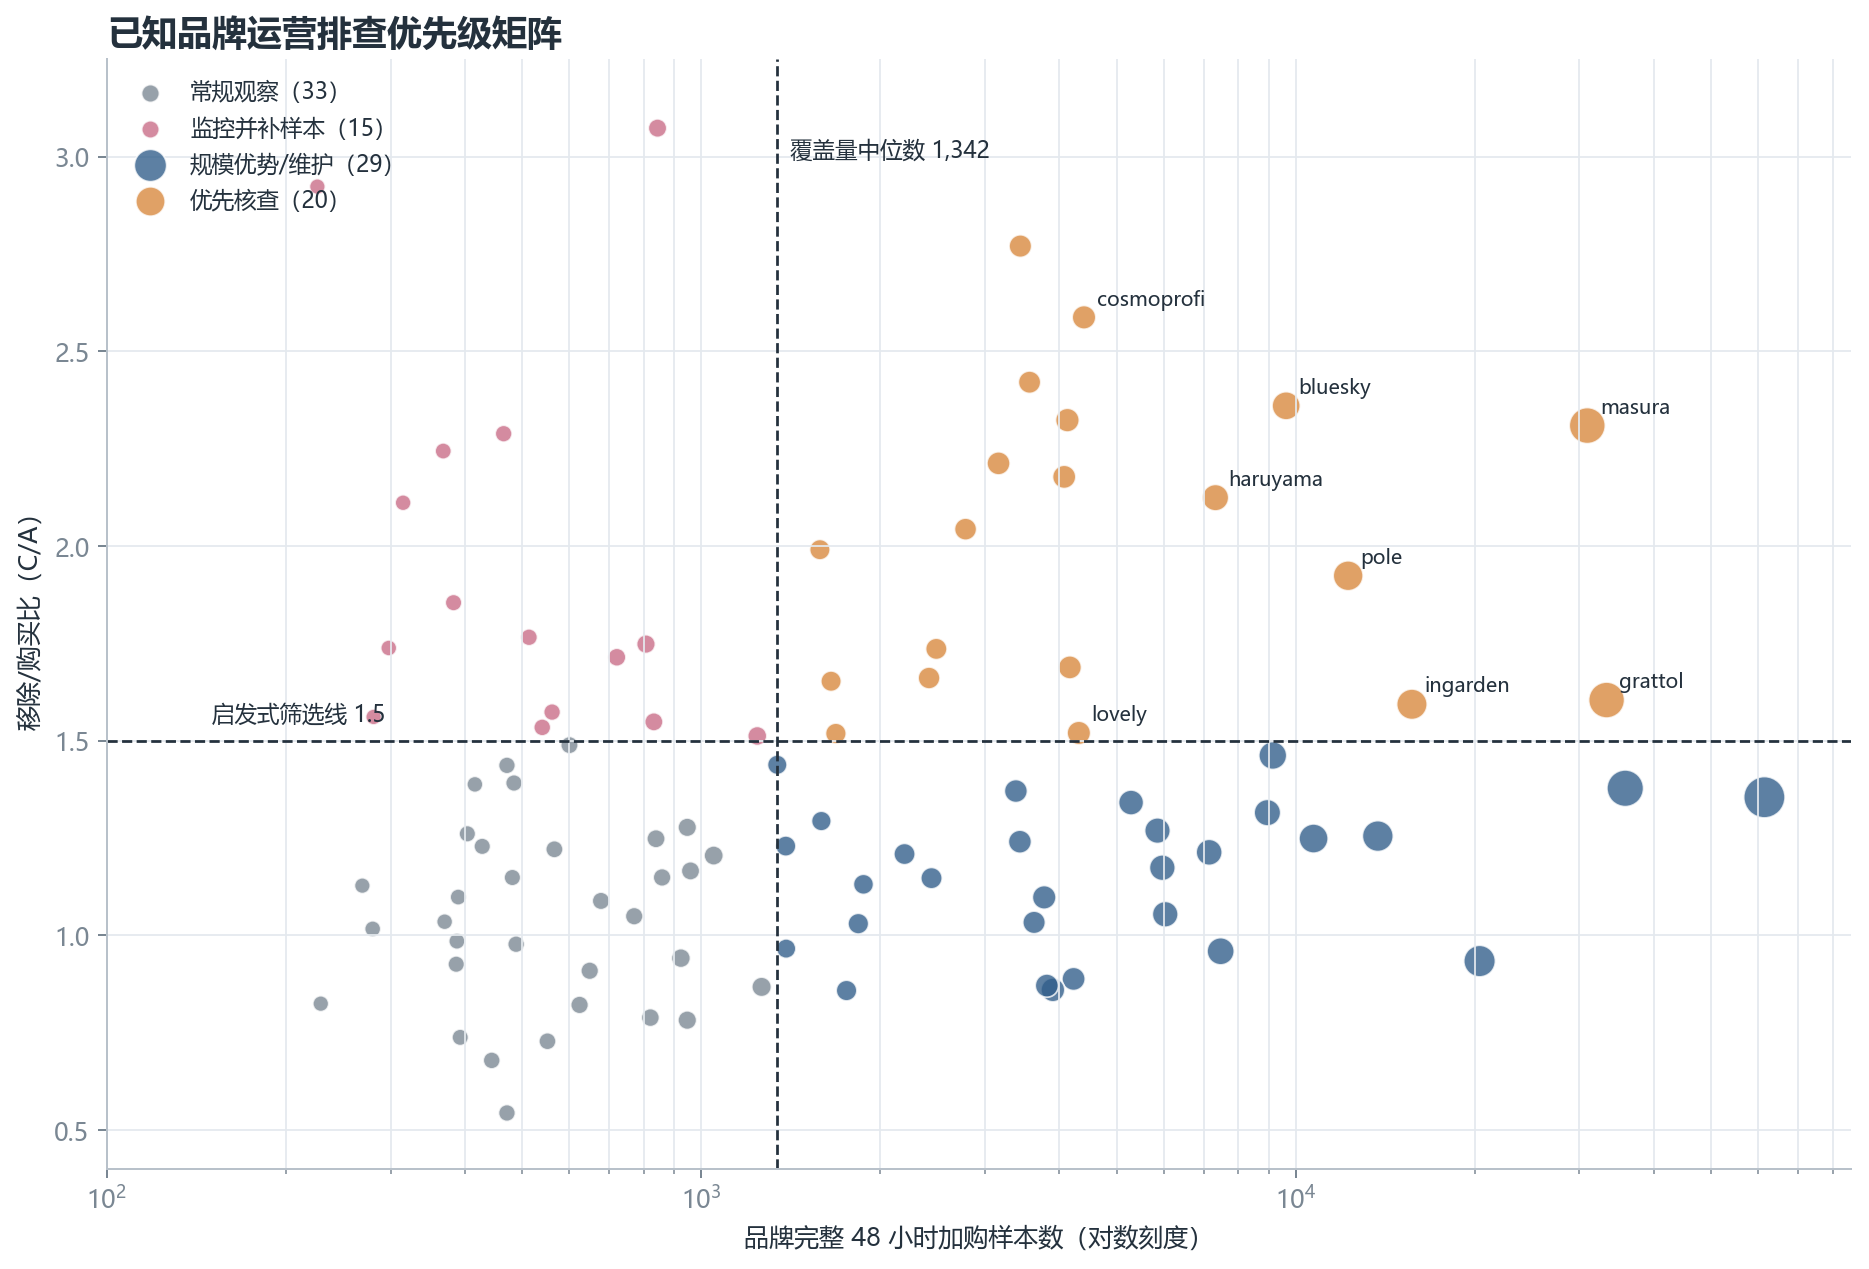

In [8]:
display(Image(filename=str(CHART_DIR / "13_brand_priority_matrix.png"), width=1000))

**解释：** “优先核查”要求品牌覆盖量不低于符合样本要求品牌的中位数，且移除/购买比达到 1.5。覆盖量使用 A+B+C，不再忽略未明确处置 B。点大小表示明确结果样本量 A+C。

## Takeaways

1. **先修口径，再谈品牌。** 原项目最严重的风险不是图表样式，而是把未知品牌 `NaN` 当真实品牌、把无效会话 `NaN` 当同一会话，以及把会话—商品数量称为人数。
2. **B 类是业务事实。** 48 小时内多数加购没有购买或移除，不能只在 A/C 子样本里报告转化。
3. **优先名单只用于排查。** `grattol`、`masura` 等品牌应先拆到 SKU 并核查库存、费用、配送承诺和结账日志；现有数据不能证明品牌导致移除。
4. **下一步应是补数据和实验。** 补充业务时区、库存、促销、运费、渠道及错误日志，用 48 小时购买率作为实验主指标，并设置用户体验护栏。